# L4 BMD & Microarchitecture — *Practical Pipeline v5 (YOLOv8-seg)*

### *"The measurement of spinal bone architecture following hip surgery using X-ray datasets"*

A **practical, measurement-focused** pipeline. The L4 vertebra is segmented with the
**YOLOv8-seg** instance model (the most reliable L4 extractor in our experiments — instance
detection naturally resolves *which* vertebra is L4 and recovers it via a top→bottom fallback),
and the same **measurement science** as v2 is layered on top:

- **Bone Mineral Density (BMD)** — area-based density index from the *linear* (uncorrected)
  normalized intensity inside the predicted L4 ROI.
- **Bone Microarchitecture** — GLCM texture descriptors (Contrast, Correlation, Energy/ASM,
  Homogeneity) of the L4 trabecular region.
- **Evaluation** against the DICOM test ground-truth L4 masks (Dice / IoU / Precision / Recall,
  confusion matrix, Bland–Altman BMD agreement).
- **XAI** — an **L4-localized Eigen-CAM** that, unlike a deep-bottleneck Grad-CAM, places the
  attribution heatmap on the L4 body and its trabecular structure.

> Design note: segmentation is a **swappable module**. We use YOLOv8-seg here because it gives the
> best L4 masks; the BMD/GLCM/eval/XAI code is segmenter-agnostic. (A from-scratch ResNet-U-Net
> variant lives in `L4_AP_segmentation_v2.ipynb`.)

> ⚠️ **Clinical caveat.** Planar-radiograph "density" is an *uncorrected radiological proxy*
> (pixel intensity), **not** true areal BMD (g/cm²). Absolute BMD needs DXA/QCT or an in-image
> calibration phantom. Values below are relative indices for methodological demonstration.

> **v4 change:** model **training on BUU-LSPINE-2000 (AP, L1..L5)** is restored as an active, guarded step (see *Step 2*). The 42 DICOMs remain a held-out **test set only**. Re-training reproduces the BUU-domain model; it does not by itself remove the out-of-domain L4 indexing gap on the DICOM test set.


> **v5 change:** the XAI is replaced by a **true gradient-based Seg-Grad-CAM** targeting the L4 instance mask (adapted from the `SemanticSegmentationTarget` Grad-CAM in `005-0614_L4_segmentation_BMD.ipynb`), plus a **BMD-contribution intensity heatmap**. The v4 gradient-free Eigen-CAM placed its heatmap off the L4 body; the v5 CAM lands on it.


## 1. Clinical Definitions & Mathematical Formulation

### 1.1 Bone Mineral Density (BMD) — area-based intensity proxy
With the X-ray linearly normalized to $[0,1]$ and $\Omega_{L4}$ the predicted L4 ROI:
$$\text{BMD}_{\text{index}}=\frac{1}{|\Omega_{L4}|}\sum_{(x,y)\in\Omega_{L4}} I_{\text{norm}}(x,y),
\qquad I_{\text{norm}}=\frac{I-I_{\min}}{I_{\max}-I_{\min}}.$$
We use the **linear** (CLAHE-free) intensity for BMD so the density meaning is preserved, and report
median / std / p10 / p90 for distribution robustness.

### 1.2 Microarchitecture — Gray-Level Co-occurrence Matrix (GLCM)
Quantising the ROI to $L=32$ levels and averaging $P_\delta$ over
$\theta\in\{0,45,90,135^\circ\}$ at $d=1$:
$$\textbf{Contrast}=\sum_{i,j}(i-j)^2P(i,j),\quad \textbf{Energy/ASM}=\sum_{i,j}P(i,j)^2,$$
$$\textbf{Correlation}=\sum_{i,j}\frac{(i-\mu_i)(j-\mu_j)P(i,j)}{\sigma_i\sigma_j},\quad
\textbf{Homogeneity}=\sum_{i,j}\frac{P(i,j)}{1+|i-j|}.$$
Dense trabecular bone ⇒ high Energy/Homogeneity, low Contrast; disrupted/osteoporotic bone ⇒ higher
Contrast, lower Correlation.

## 0. Environment & Imports

Target: **Windows + RTX 5060 Laptop (CUDA)**. Requires `ultralytics` (YOLOv8). Uncomment to install.

In [1]:
# !pip install ultralytics pydicom pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg \
# !             opencv-python-headless scikit-image scikit-learn matplotlib seaborn pandas

import os, glob, re, random, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import graycomatrix, graycoprops
from ultralytics import YOLO

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
random.seed(42); np.random.seed(42)
print("OpenCV:", cv2.__version__)

OpenCV: 4.13.0


## 2. Configuration & Paths

In [2]:
# -------------------- Paths --------------------
BUU_ROOT      = "./BUU-LSPINE-2000/AP"
IMG_DIR       = os.path.join(BUU_ROOT, "images")
LBL_DIR       = os.path.join(BUU_ROOT, "labels")
TEST_DCM_DIR  = "./dataset-dcm/test/gather"
TEST_MASK_DIR = "./dataset-dcm/test/gather_mask/SegmentationClass"   # L4 ground-truth (PNG)
OUT_DIR       = "./l4_v4_output"
os.makedirs(OUT_DIR, exist_ok=True)

# -------------------- Model / Training --------------------
YOLO_PROJECT = "runs/segment/ap_seg"      # ultralytics project dir
YOLO_NAME    = "l1_l5"                     # run name
YOLO_WEIGHTS = os.path.join(YOLO_PROJECT, YOLO_NAME, "weights", "best.pt")
YOLO_BASE    = "yolov8s-seg.pt"            # base checkpoint for (re)training on BUU-LSPINE-2000
CONF         = 0.25

# Training controls (BUU-LSPINE-2000 AP, classes L1..L5). The 42 DICOMs are TEST-ONLY.
RETRAIN      = False     # True -> retrain from YOLO_BASE; False -> reuse best.pt if it exists
EPOCHS       = 100
IMGSZ        = 640
VAL_RATIO    = 0.15      # BUU train/val split (test = DICOM set, never used here)
SEED         = 42
random.seed(SEED); np.random.seed(SEED)

# -------------------- Task --------------------
CLASS_NAMES = ["L1", "L2", "L3", "L4", "L5"]
L4_IDX      = CLASS_NAMES.index("L4")    # = 3
GLCM_LEVELS = 32
ROI_SHRINK  = 0.85                       # shrink mask toward centre -> cancellous-bone ROI

if os.path.exists(YOLO_WEIGHTS):
    print("Weights:", YOLO_WEIGHTS, "(set RETRAIN=True in Step 2 to retrain on BUU-LSPINE-2000)")
else:
    print(f"[note] No weights at {YOLO_WEIGHTS} yet -> Step 2 will train on BUU-LSPINE-2000.")


Weights: runs/segment/ap_seg\l1_l5\weights\best.pt (set RETRAIN=True in Step 2 to retrain on BUU-LSPINE-2000)


### Image loaders (JPG / DICOM)

Each loader returns **two views** from one X-ray:
- `rgb_uint8` — a display-normalized 3-channel image **fed to YOLO** (matches its training tone:
  bright bone, percentile-windowed; MONOCHROME1 DICOMs are inverted).
- `gray_lin` — a **linear** min–max normalized grayscale used for **BMD/GLCM** (no CLAHE, so the
  density meaning is preserved).

In [3]:
def load_xray(path):
    '''Return (rgb_uint8 for YOLO, gray_lin float[0,1] for BMD/GLCM, H, W).'''
    ext = os.path.splitext(path)[1].lower()
    if ext == ".dcm":
        import pydicom
        ds  = pydicom.dcmread(path)
        raw = ds.pixel_array.astype(np.float32)
        raw = raw * float(getattr(ds, "RescaleSlope", 1.0)) + float(getattr(ds, "RescaleIntercept", 0.0))
        if str(getattr(ds, "PhotometricInterpretation", "")).upper() == "MONOCHROME1":
            raw = raw.max() - raw                      # bright bone, linear
        lo, hi = np.percentile(raw, 0.5), np.percentile(raw, 99.5)
        if hi <= lo:
            lo, hi = raw.min(), raw.max() + 1e-6
        rgb = cv2.cvtColor((np.clip((raw - lo) / (hi - lo), 0, 1) * 255).astype(np.uint8),
                           cv2.COLOR_GRAY2RGB)
        gray_lin = (raw - raw.min()) / (raw.max() - raw.min() + 1e-6)
        H, W = raw.shape
        return rgb, gray_lin.astype(np.float32), H, W
    g = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if g is None:
        raise FileNotFoundError(path)
    rgb = cv2.cvtColor(g, cv2.COLOR_GRAY2RGB)
    gray_lin = (g.astype(np.float32) - g.min()) / (g.max() - g.min() + 1e-6)
    return rgb, gray_lin, g.shape[0], g.shape[1]

def list_pairs():
    pairs = []
    for lp in sorted(glob.glob(os.path.join(LBL_DIR, "*"))):
        stem = os.path.splitext(os.path.basename(lp))[0]
        for ext in (".jpg", ".jpeg", ".png"):
            ip = os.path.join(IMG_DIR, stem + ext)
            if os.path.exists(ip):
                pairs.append(ip); break
    return pairs

buu_imgs      = list_pairs()
test_dcm_files = sorted(glob.glob(os.path.join(TEST_DCM_DIR, "*.dcm")))
eval_items = [p for p in test_dcm_files
              if os.path.exists(os.path.join(TEST_MASK_DIR,
                 os.path.splitext(os.path.basename(p))[0] + ".png"))]
print(f"BUU images: {len(buu_imgs)} | DICOM test: {len(test_dcm_files)} "
      f"({len(eval_items)} with L4 ground truth)")

BUU images: 2000 | DICOM test: 42 (42 with L4 ground truth)


## Step 1 — Data Loading (visualization)

Sample raw X-rays with their intensity histograms.

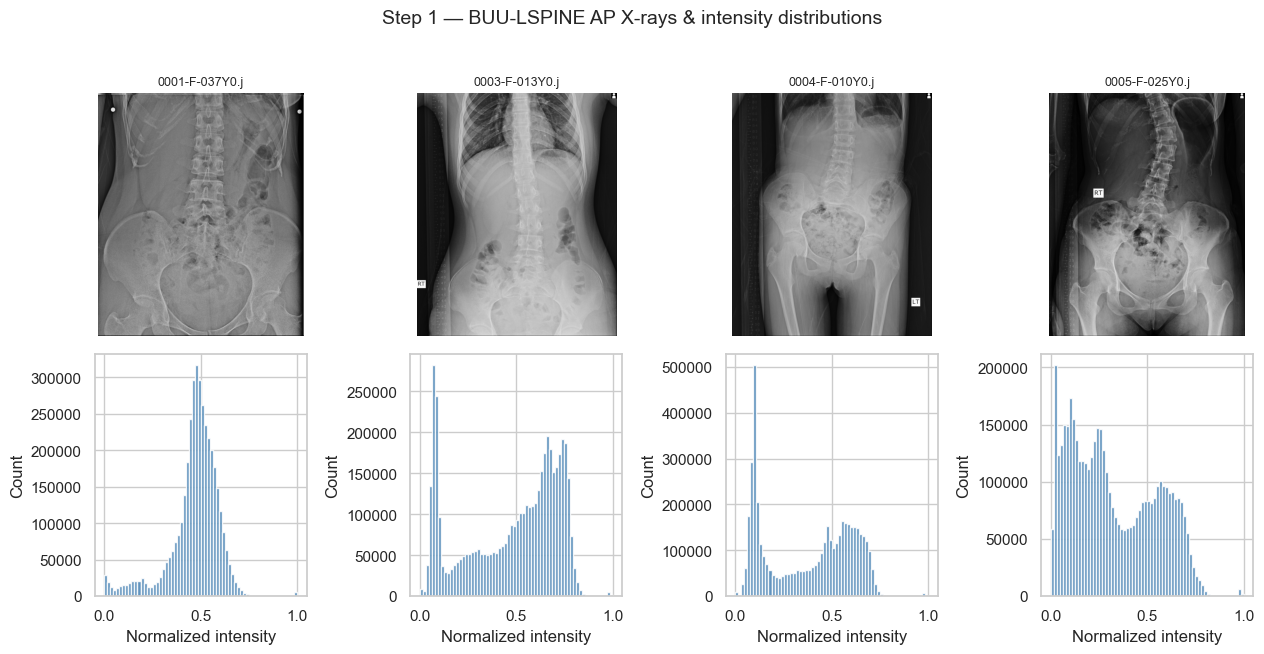

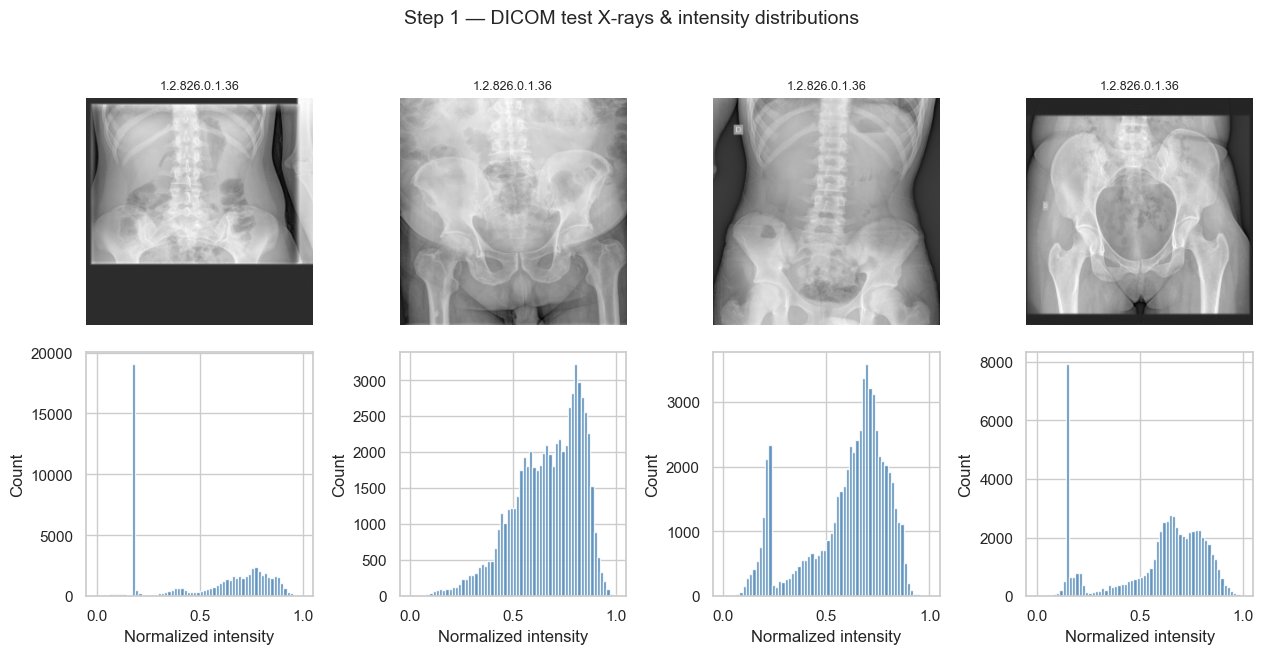

In [4]:
def show_raw_with_histograms(paths, title):
    n = len(paths)
    fig, axes = plt.subplots(2, n, figsize=(3.2 * n, 6.4))
    for k, p in enumerate(paths):
        _, g, _, _ = load_xray(p)
        axes[0, k].imshow(g, cmap="gray"); axes[0, k].set_title(os.path.basename(p)[:14], fontsize=9)
        axes[0, k].axis("off")
        axes[1, k].hist(g.ravel(), bins=64, color="steelblue", alpha=0.85)
        axes[1, k].set_xlabel("Normalized intensity"); axes[1, k].set_ylabel("Count")
    fig.suptitle(title, fontsize=14, y=1.02); plt.tight_layout(); plt.show()

show_raw_with_histograms(buu_imgs[:4], "Step 1 — BUU-LSPINE AP X-rays & intensity distributions")
if eval_items:
    show_raw_with_histograms(eval_items[:4], "Step 1 — DICOM test X-rays & intensity distributions")

## Step 2 — Train (or load) the YOLOv8-seg model on **BUU-LSPINE-2000**

The L4 extractor is a **YOLOv8-seg** instance model trained on the **BUU-LSPINE-2000 (AP)** set
(2000 X-rays, 5 vertebra classes L1..L5). The 4-corner CSV labels are converted to YOLO-seg
polygons and the model is trained with a deterministic train/val split.

- **`RETRAIN=False`** (default): reuse the existing `best.pt` if present (reproducible, no forced
  multi-hour retrain).
- **`RETRAIN=True`** *or* missing weights: (re)train from `YOLO_BASE` and write to
  `runs/segment/ap_seg/l1_l5/weights/best.pt`.

> The **42 DICOMs are a held-out test set** and never enter training or validation here.


In [5]:
import shutil

# ---- CSV (4-corner quads) -> ordered L1..L5 polygons --------------------------
def _csv_rows(path):
    out = []
    for line in open(path):
        nums = re.findall(r"-?\d+\.?\d*", line)
        if len(nums) >= 4:
            out.append([float(v) for v in nums[:4]])   # xL, yL, xR, yR
    return out

def order_quad(pts):
    '''4 points -> [TL, TR, BR, BL] (clockwise, non-self-intersecting).'''
    pts = sorted(pts, key=lambda p: p[1])      # by y
    top = sorted(pts[:2], key=lambda p: p[0])  # upper two: left, right
    bot = sorted(pts[2:], key=lambda p: p[0])  # lower two: left, right
    return [top[0], top[1], bot[1], bot[0]]

def parse_polys(path, n_vert=len(CLASS_NAMES), lines_per=2):
    '''Return n_vert quads ordered L1..L5 (top->bottom), or [] if malformed.'''
    rows = _csv_rows(path)
    if len(rows) < lines_per * n_vert:
        return []
    verts = []
    for i in range(n_vert):
        pts = []
        for j in range(lines_per):
            xL, yL, xR, yR = rows[i * lines_per + j]
            pts += [(xL, yL), (xR, yR)]
        q = order_quad(pts)
        verts.append((sum(p[1] for p in q) / 4.0, q))
    verts.sort(key=lambda v: v[0])             # top -> bottom => L1..L5
    return [q for _, q in verts]

def build_yolo_dataset(root="./yolo_ap_seg", val_ratio=VAL_RATIO, seed=SEED):
    '''Convert BUU-LSPINE labels to a YOLO-seg dataset; return (data.yaml, n_train, n_val).'''
    pairs = []
    for lp in sorted(glob.glob(os.path.join(LBL_DIR, "*.csv"))):
        stem = os.path.splitext(os.path.basename(lp))[0]
        ip = next((os.path.join(IMG_DIR, stem + e) for e in (".jpg", ".jpeg", ".png")
                   if os.path.exists(os.path.join(IMG_DIR, stem + e))), None)
        if ip and len(parse_polys(lp)) == len(CLASS_NAMES):
            pairs.append((ip, lp))
    random.Random(seed).shuffle(pairs)
    n_val = int(len(pairs) * val_ratio)
    split = {"val": pairs[:n_val], "train": pairs[n_val:]}
    for sub in ["images/train", "images/val", "labels/train", "labels/val"]:
        d = os.path.join(root, sub)
        if os.path.exists(d):
            shutil.rmtree(d)
        os.makedirs(d, exist_ok=True)
    for sp, plist in split.items():
        for ip, lp in plist:
            stem = os.path.splitext(os.path.basename(ip))[0]
            H, W = cv2.imread(ip).shape[:2]
            shutil.copy(ip, os.path.join(root, "images", sp, os.path.basename(ip)))
            with open(os.path.join(root, "labels", sp, stem + ".txt"), "w") as f:
                for cid, q in enumerate(parse_polys(lp)):
                    coords = " ".join(f"{x / W:.6f} {y / H:.6f}" for x, y in q)
                    f.write(f"{cid} {coords}\n")
    yaml_path = os.path.join(root, "data.yaml")
    with open(yaml_path, "w") as f:
        f.write(f"path: {os.path.abspath(root)}\ntrain: images/train\nval: images/val\n")
        f.write(f"nc: {len(CLASS_NAMES)}\nnames: {CLASS_NAMES}\n")
    return yaml_path, len(split["train"]), len(split["val"])

# ---- Train (guarded) or reuse existing weights --------------------------------
if RETRAIN or not os.path.exists(YOLO_WEIGHTS):
    print("Preparing YOLO-seg dataset from BUU-LSPINE-2000 ...")
    data_yaml, n_tr, n_va = build_yolo_dataset()
    print(f"  train={n_tr}  val={n_va}  | test DICOMs held out: {len(test_dcm_files)}")
    print(f"Training {YOLO_BASE} for {EPOCHS} epochs @ imgsz={IMGSZ} (batch=auto) ...")
    YOLO(YOLO_BASE).train(data=data_yaml, epochs=EPOCHS, imgsz=IMGSZ, batch=-1,
                          project=YOLO_PROJECT, name=YOLO_NAME, patience=20,
                          workers=0, seed=SEED, exist_ok=True)
else:
    print(f"Reusing existing weights -> {YOLO_WEIGHTS}  (set RETRAIN=True to retrain).")

assert os.path.exists(YOLO_WEIGHTS), f"Training did not produce weights at {YOLO_WEIGHTS}"
seg = YOLO(YOLO_WEIGHTS)
print("Loaded YOLOv8-seg:", YOLO_WEIGHTS)


Reusing existing weights -> runs/segment/ap_seg\l1_l5\weights\best.pt  (set RETRAIN=True to retrain).
Loaded YOLOv8-seg: runs/segment/ap_seg\l1_l5\weights\best.pt


### Step 2b — Training & Validation diagnostics (BUU-LSPINE val set)

These are the **in-domain** results on the BUU-LSPINE validation split, recovered from the saved run
directory `runs/segment/ap_seg/l1_l5/`. They were never actually missing: with `RETRAIN=False` the
training cell only reloads `best.pt`, so Ultralytics never re-emits its plots into the notebook. We
surface them here (training curves, confusion matrix, PR curves, val-batch predictions) so the
validation result is always visible.

> The model is **excellent in-domain** (Mask mAP@50 ≈ 0.97, P/R ≈ 0.95). The weak numbers in Step 4
> are **not** a segmentation failure — they come from an L4 *naming / indexing* gap on the
> out-of-domain DICOM test set, quantified explicitly in Step 4.

BUU-LSPINE held-out VALIDATION (epoch 50 -> best.pt):
  Mask precision  : 0.9527
  Mask recall     : 0.9568
  Mask mAP@50     : 0.9708
  Mask mAP@50-95  : 0.7622
  (IN-DOMAIN BUU metrics. The DICOM test set is evaluated separately in Step 4.)

[note] ./yolo_ap_seg\data.yaml absent (dataset not rebuilt this session) -> showing saved plots only.


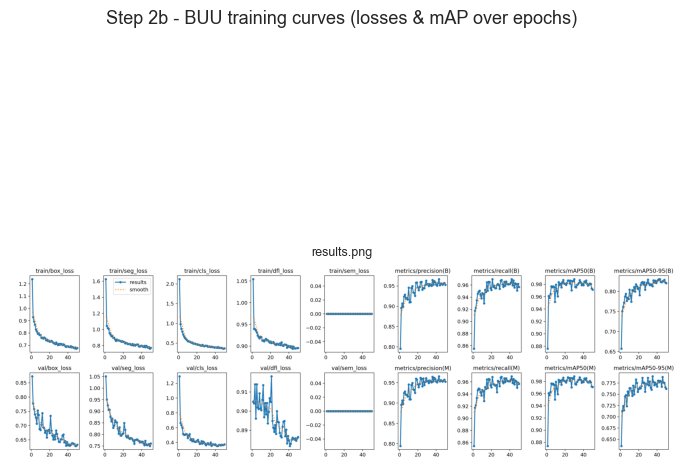

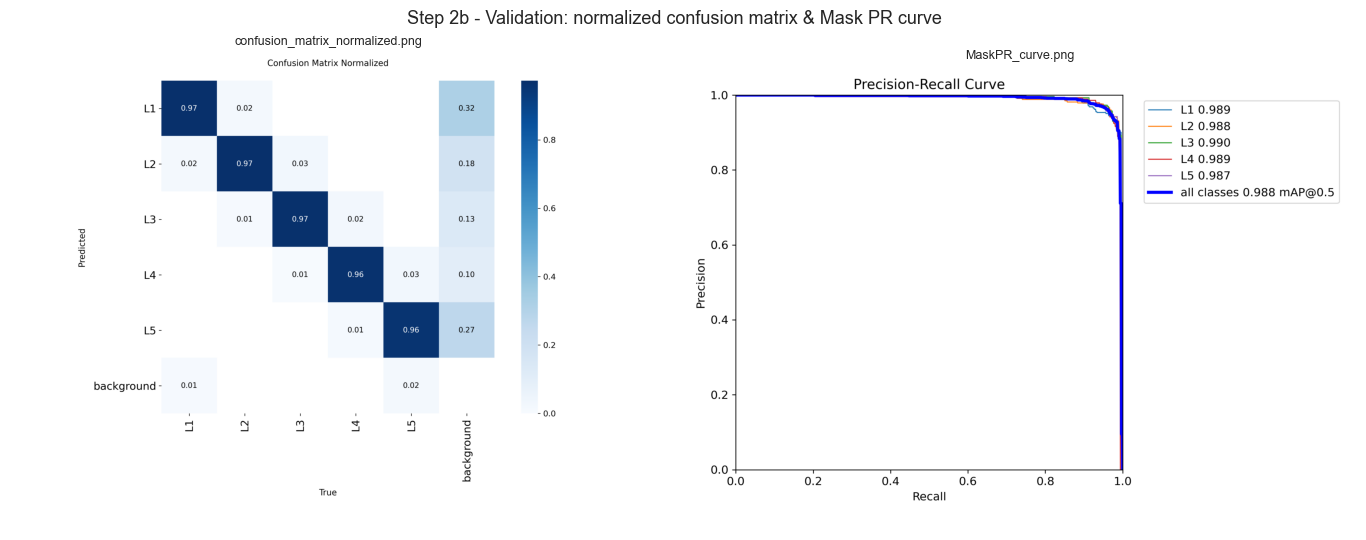

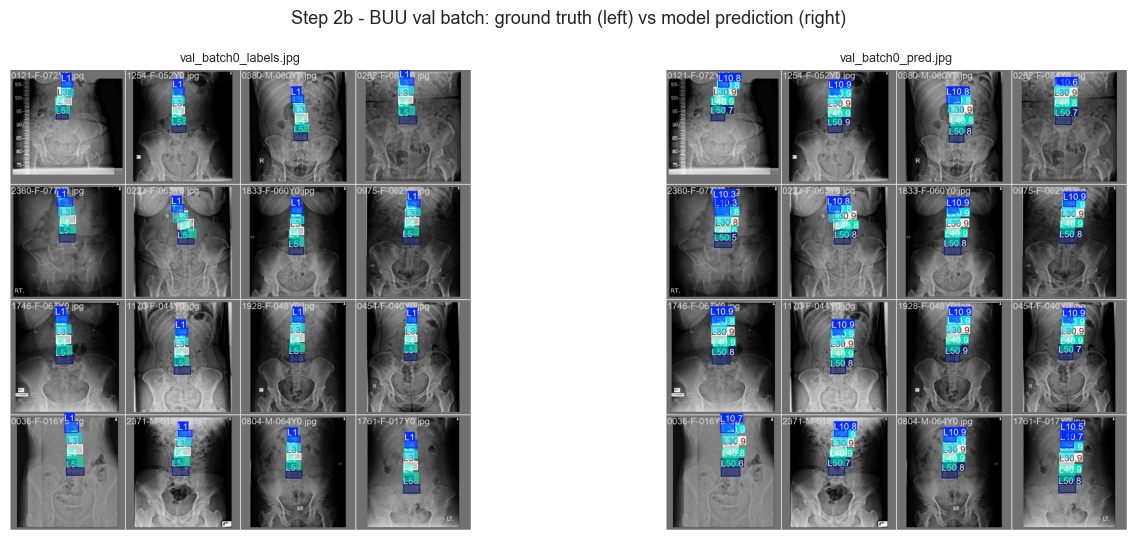

In [6]:
# ---- Step 2b — Surface the BUU-LSPINE training/validation diagnostics ----
# Ultralytics auto-generates these plots DURING training and saves them in the run dir.
# With RETRAIN=False the cell above only *loads* best.pt, so they are never re-emitted into
# the notebook (this is why the validation results "disappeared"). We display the saved ones
# here so the BUU-domain validation result is always visible, retrain-or-not.
import matplotlib.image as mpimg

RUN_DIR = os.path.join(YOLO_PROJECT, YOLO_NAME)

# (1) Final validation metrics (last row of results.csv)
rc_path = os.path.join(RUN_DIR, "results.csv")
if os.path.exists(rc_path):
    rdf = pd.read_csv(rc_path); rdf.columns = [c.strip() for c in rdf.columns]
    last = rdf.iloc[-1]
    print(f"BUU-LSPINE held-out VALIDATION (epoch {int(last['epoch'])} -> best.pt):")
    for k, lbl in [("metrics/precision(M)", "Mask precision"),
                   ("metrics/recall(M)",    "Mask recall"),
                   ("metrics/mAP50(M)",     "Mask mAP@50"),
                   ("metrics/mAP50-95(M)",  "Mask mAP@50-95")]:
        if k in rdf.columns:
            print(f"  {lbl:16s}: {last[k]:.4f}")
    print("  (IN-DOMAIN BUU metrics. The DICOM test set is evaluated separately in Step 4.)")
else:
    print(f"[note] {rc_path} not found -> train at least once (RETRAIN=True) to generate it.")

# (2) Optional live re-validation on the BUU val split (only if the dataset still exists)
data_yaml = os.path.join("./yolo_ap_seg", "data.yaml")
if os.path.exists(data_yaml):
    print("\nRunning live seg.val() on the BUU val split ...")
    vm = seg.val(data=data_yaml, split="val", verbose=False)
    try:
        print(f"  live -> Mask mAP@50={vm.seg.map50:.4f}  mAP@50-95={vm.seg.map:.4f}")
    except Exception:
        pass
else:
    print(f"\n[note] {data_yaml} absent (dataset not rebuilt this session) -> showing saved plots only.")

# (3) Display the saved diagnostic images
def _show_run_imgs(names, title, ncol=2, h=5.5):
    paths = [(n, os.path.join(RUN_DIR, n)) for n in names
             if os.path.exists(os.path.join(RUN_DIR, n))]
    if not paths:
        print(f"[note] none of {names} found in {RUN_DIR}"); return
    nrow = int(np.ceil(len(paths) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(7.0 * ncol, h * nrow))
    axes = np.atleast_1d(axes).ravel()
    for a in axes: a.axis("off")
    for a, (n, p) in zip(axes, paths):
        a.imshow(mpimg.imread(p)); a.set_title(n, fontsize=9); a.axis("off")
    fig.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()

_show_run_imgs(["results.png"], "Step 2b - BUU training curves (losses & mAP over epochs)", ncol=1, h=7)
_show_run_imgs(["confusion_matrix_normalized.png", "MaskPR_curve.png"],
               "Step 2b - Validation: normalized confusion matrix & Mask PR curve")
_show_run_imgs(["val_batch0_labels.jpg", "val_batch0_pred.jpg"],
               "Step 2b - BUU val batch: ground truth (left) vs model prediction (right)")

### L4 extraction & visualization

The trained model detects L1–L5 as instances. The L4 mask is chosen by **class** when available,
else by the **4th-from-top** rule (vertebrae ordered by vertical centroid) — so L4 is essentially
never dropped. The polygon is rasterised to a binary mask at the image's native resolution.

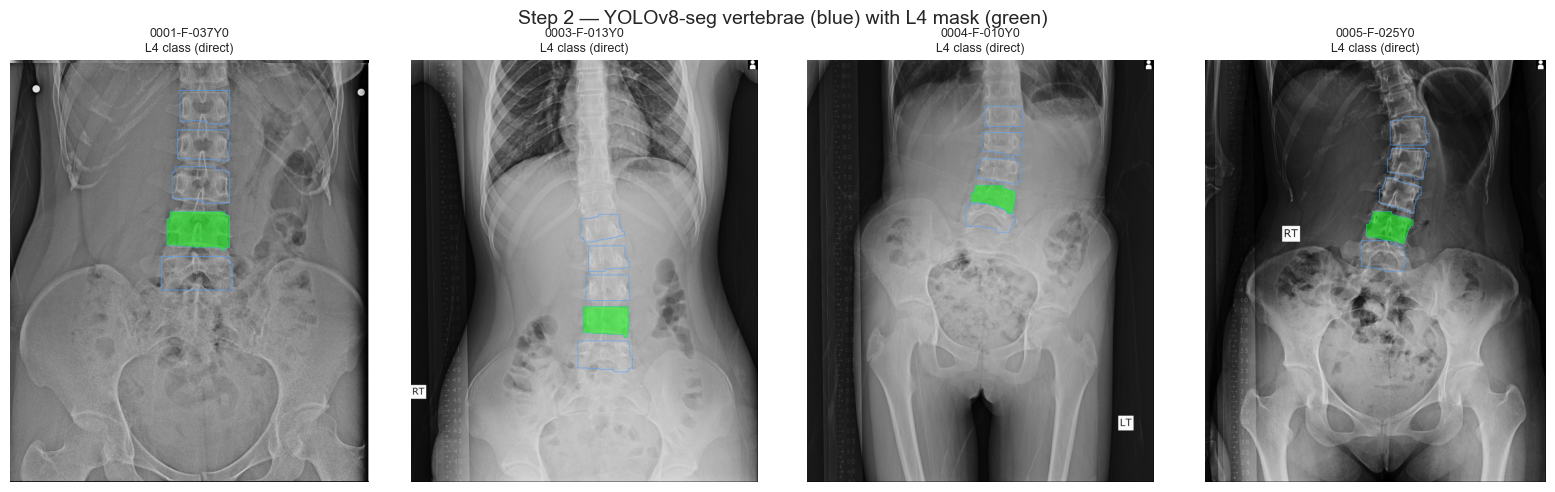

In [7]:
# seg already trained/loaded in Step 2

def poly_to_mask(poly_xy, H, W, shrink=1.0):
    poly = np.asarray(poly_xy, np.float32)
    if shrink != 1.0 and len(poly):
        ctr = poly.mean(0); poly = ctr + shrink * (poly - ctr)
    m = np.zeros((H, W), np.uint8)
    if len(poly):
        cv2.fillPoly(m, [poly.astype(np.int32)], 1)
    return m

def pick_l4_index(boxes_xyxy, classes, confs):
    '''Choose the L4 instance: direct class, else 4th vertebra from the top (fallback).'''
    if len(boxes_xyxy) == 0:
        return None, "no detection"
    idx = [i for i, c in enumerate(classes) if c == L4_IDX]
    if idx:
        return max(idx, key=lambda i: confs[i]), "L4 class (direct)"
    order = sorted(range(len(boxes_xyxy)), key=lambda i: (boxes_xyxy[i][1] + boxes_xyxy[i][3]) / 2)
    if len(order) >= 4:
        return order[3], "4th-from-top (fallback)"
    return None, f"only {len(boxes_xyxy)} vertebrae"

def yolo_l4(rgb, conf=CONF, shrink=1.0):
    '''Run YOLO and return (l4_mask[H,W] or None, status, result).'''
    r = seg.predict(rgb, conf=conf, verbose=False)[0]
    H, W = rgb.shape[:2]
    if r.masks is None or len(r.boxes) == 0:
        return None, "no detection", r
    boxes = r.boxes.xyxy.cpu().numpy()
    classes = r.boxes.cls.cpu().numpy().astype(int)
    confs = r.boxes.conf.cpu().numpy()
    i, status = pick_l4_index(boxes, classes, confs)
    if i is None:
        return None, status, r
    return poly_to_mask(r.masks.xy[i], H, W, shrink), status, r

# ---- Visualization: YOLO segmentation with L4 highlighted ----
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for k, p in enumerate(buu_imgs[:4]):
    rgb, _, H, W = load_xray(p)
    m, status, r = yolo_l4(rgb)
    vis = rgb.copy()
    if r.masks is not None:
        for poly in r.masks.xy:
            cv2.polylines(vis, [poly.astype(np.int32)], True, (80, 160, 255), 2)
    if m is not None:
        vis[m > 0] = (0.5 * vis[m > 0] + 0.5 * np.array([0, 255, 0])).astype(np.uint8)
    axes[k].imshow(vis); axes[k].set_title(f"{os.path.basename(p)[:12]}\n{status}", fontsize=9)
    axes[k].axis("off")
fig.suptitle("Step 2 — YOLOv8-seg vertebrae (blue) with L4 mask (green)", fontsize=14)
plt.tight_layout(); plt.show()

## Step 3 — BMD & GLCM Extractors

In [8]:
def shrink_mask(mask, shrink=ROI_SHRINK):
    if shrink >= 1.0:
        return mask
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return mask
    cx, cy = xs.mean(), ys.mean()
    out = np.zeros_like(mask)
    nx = np.clip((cx + shrink * (xs - cx)).astype(int), 0, mask.shape[1] - 1)
    ny = np.clip((cy + shrink * (ys - cy)).astype(int), 0, mask.shape[0] - 1)
    out[ny, nx] = 1
    return cv2.morphologyEx(out, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))

def compute_bmd(img_norm, mask):
    vals = img_norm[mask > 0]
    if vals.size == 0:
        return None
    return {"area_px": int(vals.size), "bmd_mean": float(vals.mean()),
            "bmd_median": float(np.median(vals)), "bmd_std": float(vals.std()),
            "bmd_p10": float(np.percentile(vals, 10)), "bmd_p90": float(np.percentile(vals, 90))}

def compute_glcm(img_norm, mask, levels=GLCM_LEVELS):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
    roi  = (img_norm[y0:y1, x0:x1] * (levels - 1)).astype(np.uint8)
    mroi = mask[y0:y1, x0:x1]
    roi[mroi == 0] = 0
    glcm = graycomatrix(roi, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=levels, symmetric=True, normed=True)
    return {"glcm_contrast": float(graycoprops(glcm, "contrast").mean()),
            "glcm_correlation": float(graycoprops(glcm, "correlation").mean()),
            "glcm_energy": float(graycoprops(glcm, "energy").mean()),
            "glcm_homogeneity": float(graycoprops(glcm, "homogeneity").mean())}

def load_test_gt_l4(dcm_path, H, W):
    '''Binary L4 ground-truth mask (PNG) resized to (H, W).'''
    stem = os.path.splitext(os.path.basename(dcm_path))[0]
    p = os.path.join(TEST_MASK_DIR, stem + ".png")
    if not os.path.exists(p):
        return None
    m = cv2.imread(p)
    fg = (m.sum(axis=2) > 10).astype(np.uint8)
    return cv2.resize(fg, (W, H), interpolation=cv2.INTER_NEAREST)
print("Helpers ready.")

Helpers ready.


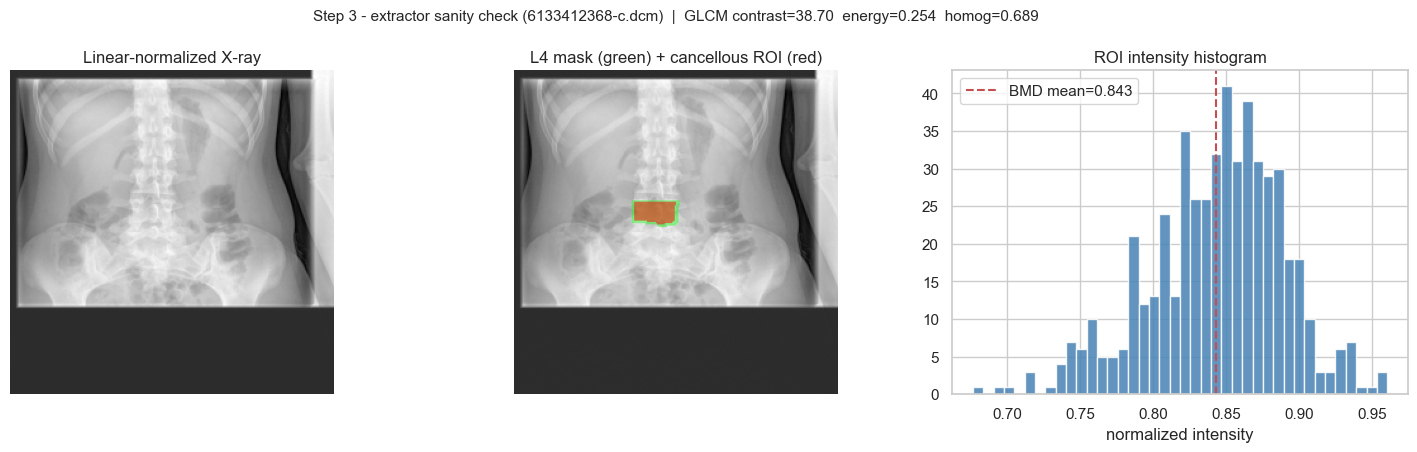

In [9]:
# ---- Step 3 demo — eye-check the BMD/GLCM extractor on one detected L4 ----
if eval_items:
    _p = eval_items[0]
    _rgb, _gl, _H, _W = load_xray(_p)
    _m, _st, _r = yolo_l4(_rgb)
    if _m is not None and _m.sum():
        _roi  = shrink_mask(_m)
        _bmd  = compute_bmd(_gl, _roi)
        _glcm = compute_glcm(_gl, _roi)
        _vis = cv2.cvtColor((_gl * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
        _vis[_m   > 0] = (0.6 * _vis[_m   > 0] + 0.4 * np.array([0, 255, 0])).astype(np.uint8)
        _vis[_roi > 0] = (0.5 * _vis[_roi > 0] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)
        fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
        ax[0].imshow(_gl, cmap="gray"); ax[0].set_title("Linear-normalized X-ray"); ax[0].axis("off")
        ax[1].imshow(_vis); ax[1].set_title("L4 mask (green) + cancellous ROI (red)"); ax[1].axis("off")
        ax[2].hist(_gl[_roi > 0].ravel(), bins=40, color="steelblue", alpha=0.85)
        ax[2].axvline(_bmd["bmd_mean"], color="r", ls="--", label=f"BMD mean={_bmd['bmd_mean']:.3f}")
        ax[2].set_title("ROI intensity histogram"); ax[2].set_xlabel("normalized intensity"); ax[2].legend()
        fig.suptitle(f"Step 3 - extractor sanity check ({os.path.basename(_p)[-16:]})  |  "
                     f"GLCM contrast={_glcm['glcm_contrast']:.2f}  energy={_glcm['glcm_energy']:.3f}  "
                     f"homog={_glcm['glcm_homogeneity']:.3f}", fontsize=11)
        plt.tight_layout(); plt.show()
    else:
        print("No L4 detected on the demo image; skipping Step 3 sanity plot.")
else:
    print("No eval_items available for the Step 3 demo.")

## Step 4 — Evaluation on the DICOM Test Set

Evaluated on `dataset-dcm/test/gather` against the **L4 ground-truth masks**, reported **two ways** so
the result is interpretable:

- **(A) Deployed** — Dice / IoU / Precision / Recall of the mask the pipeline actually *names* `L4`.
  This is the honest real-world inference number (no ground truth used to pick the vertebra).
- **(B) Matched** — Dice of the *best-overlap* detected vertebra vs the GT L4. This isolates the
  **segmentation quality** from the separate question of *which* vertebra is labelled L4.

A large **(B − A) gap** is the signature of an **L4 naming / indexing** problem — an off-by-one
vertebra on the out-of-domain DICOM field-of-view — **not** poor segmentation. The cells below show
the two metrics, diagnostic overlays (named-L4 red vs best-overlap green vs GT yellow), a per-image
Deployed-vs-Matched bar chart, the pixel confusion matrix, and a Bland–Altman BMD agreement.

In [10]:
def seg_scores(pred, gt, eps=1e-6):
    pred = pred.astype(bool); gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    dice = 2*tp / (2*tp + fp + fn + eps)
    iou = tp / (tp + fp + fn + eps)
    prec = tp / (tp + fp + eps)
    rec = tp / (tp + fn + eps)
    return dice, iou, prec, rec, int(tp), int(fp), int(fn)

def yolo_instances(rgb, conf=CONF, shrink=1.0):
    '''Run YOLO once; return (selected_L4_mask|None, status, list_of_all_instance_masks, r).'''
    r = seg.predict(rgb, conf=conf, verbose=False)[0]
    H, W = rgb.shape[:2]
    if r.masks is None or len(r.boxes) == 0:
        return None, "no detection", [], r
    boxes   = r.boxes.xyxy.cpu().numpy()
    classes = r.boxes.cls.cpu().numpy().astype(int)
    confs   = r.boxes.conf.cpu().numpy()
    inst = [poly_to_mask(r.masks.xy[i], H, W, shrink) for i in range(len(r.masks.xy))]
    i, status = pick_l4_index(boxes, classes, confs)
    sel = inst[i] if i is not None else None
    return sel, status, inst, r

def best_overlap(inst, gt):
    '''Among ALL detected vertebra instances, the one with the highest Dice vs GT.
       This isolates *segmentation quality* from *which* instance is named L4.'''
    if not inst:
        return np.zeros_like(gt), 0.0
    scored = [(seg_scores(m, gt)[0], m) for m in inst]
    d, m = max(scored, key=lambda t: t[0])
    return m, d

# ---- Dual-metric evaluation: (A) Deployed (named L4) vs (B) Matched (best-overlap) ----
rows, bmd_pred, bmd_gt = [], [], []
cm_total = np.zeros((2, 2), dtype=np.int64)
n_fail = 0
for dp in eval_items:
    rgb, gray_lin, H, W = load_xray(dp)
    sel, status, inst, r = yolo_instances(rgb)
    gt = load_test_gt_l4(dp, H, W)
    if gt is None:
        continue
    if sel is None:
        sel = np.zeros((H, W), np.uint8); n_fail += 1
    # (A) DEPLOYED: the mask the pipeline actually calls "L4" (honest real-world inference)
    d, i, p, rc, tp, fp, fn = seg_scores(sel, gt)
    # (B) MATCHED: best-overlap vertebra vs GT (segmentation quality, naming aside)
    bo_mask, d_match = best_overlap(inst, gt)
    tn = H*W - (tp + fp + fn)
    cm_total += np.array([[tn, fp], [fn, tp]], dtype=np.int64)
    rows.append({"file": os.path.basename(dp), "status": status, "n_inst": len(inst),
                 "dice": d, "iou": i, "precision": p, "recall": rc,
                 "dice_matched": d_match})
    bp = compute_bmd(gray_lin, shrink_mask(sel)) if sel.sum() else None
    bg = compute_bmd(gray_lin, shrink_mask(gt))
    if bp and bg:
        bmd_pred.append(bp["bmd_mean"]); bmd_gt.append(bg["bmd_mean"])

dfm = pd.DataFrame(rows)
print(f"Evaluated {len(dfm)} test images | L4 detection failures: {n_fail}\n")
print("=== (A) DEPLOYED — mask the model names 'L4'  (honest real-world inference) ===")
for c in ["dice", "iou", "precision", "recall"]:
    print(f"  {c.capitalize():10s}: {dfm[c].mean():.4f} +/- {dfm[c].std():.4f}")
print("\n=== (B) MATCHED — best-overlap vertebra vs GT  (segmentation quality, naming aside) ===")
print(f"  Dice      : {dfm['dice_matched'].mean():.4f} +/- {dfm['dice_matched'].std():.4f}")

n_zero = int((dfm['dice'] < 0.05).sum())
gap = dfm['dice_matched'].mean() - dfm['dice'].mean()
print(f"\n>> Indexing gap (Matched - Deployed Dice) = {gap:.4f}")
print(f">> {n_zero}/{len(dfm)} images have Deployed Dice ~ 0, yet on those same images the")
print(f"   best-overlap vertebra reaches mean Dice = "
      f"{dfm.loc[dfm['dice']<0.05, 'dice_matched'].mean():.3f}.")
print( "   => The segmenter finds a correctly-shaped L4; the pipeline just attaches the 'L4'")
print( "      label to the wrong (off-by-one) vertebra on the out-of-domain DICOM field-of-view.")
dfm.to_csv(os.path.join(OUT_DIR, "L4_test_segmetrics.csv"), index=False)

Evaluated 42 test images | L4 detection failures: 2

=== (A) DEPLOYED — mask the model names 'L4'  (honest real-world inference) ===
  Dice      : 0.2788 +/- 0.4056
  Iou       : 0.2453 +/- 0.3634
  Precision : 0.2767 +/- 0.4058
  Recall    : 0.2834 +/- 0.4106

=== (B) MATCHED — best-overlap vertebra vs GT  (segmentation quality, naming aside) ===
  Dice      : 0.7643 +/- 0.1976

>> Indexing gap (Matched - Deployed Dice) = 0.4855
>> 28/42 images have Deployed Dice ~ 0, yet on those same images the
   best-overlap vertebra reaches mean Dice = 0.728.
   => The segmenter finds a correctly-shaped L4; the pipeline just attaches the 'L4'
      label to the wrong (off-by-one) vertebra on the out-of-domain DICOM field-of-view.


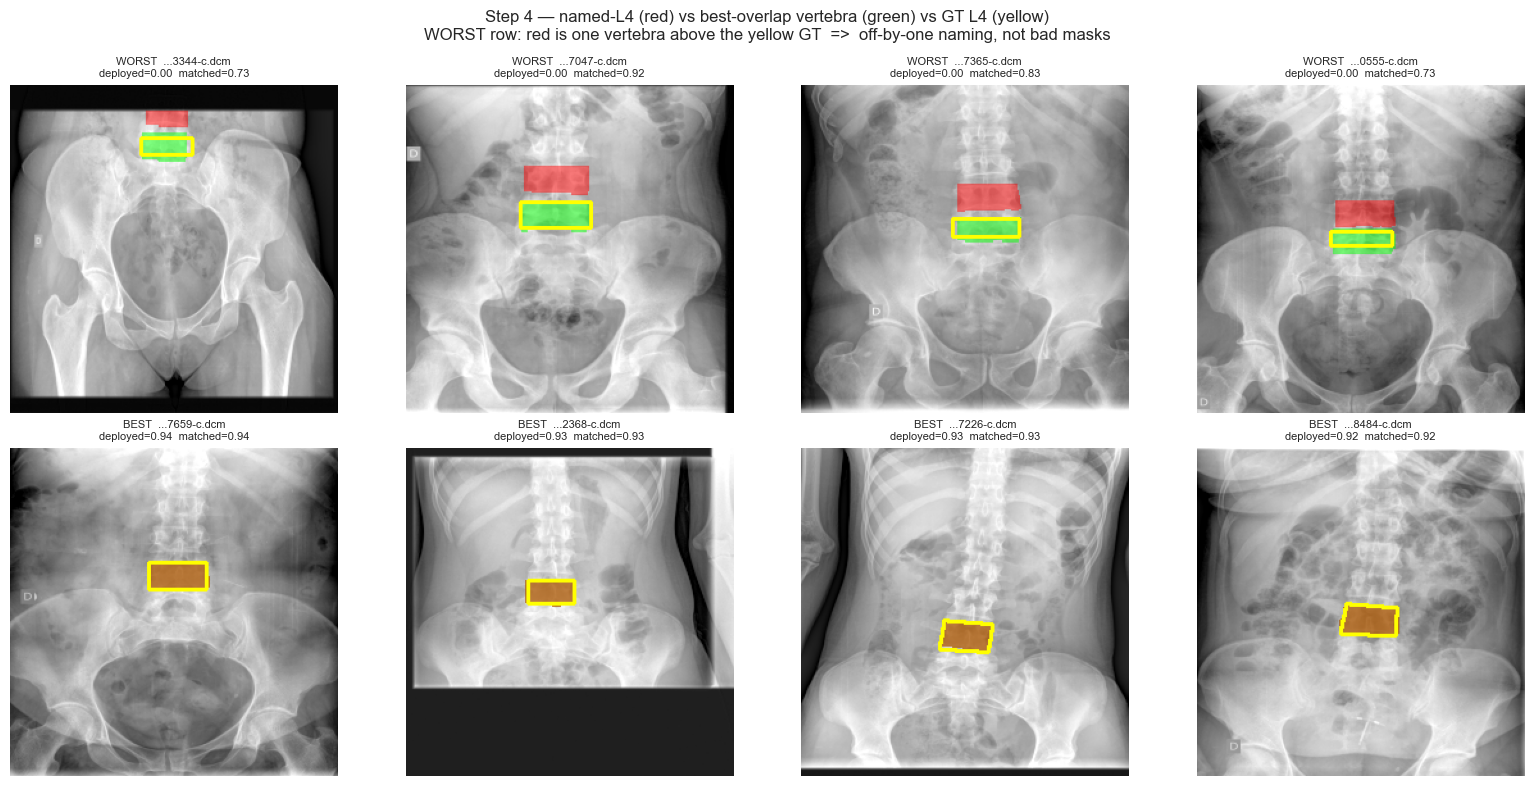

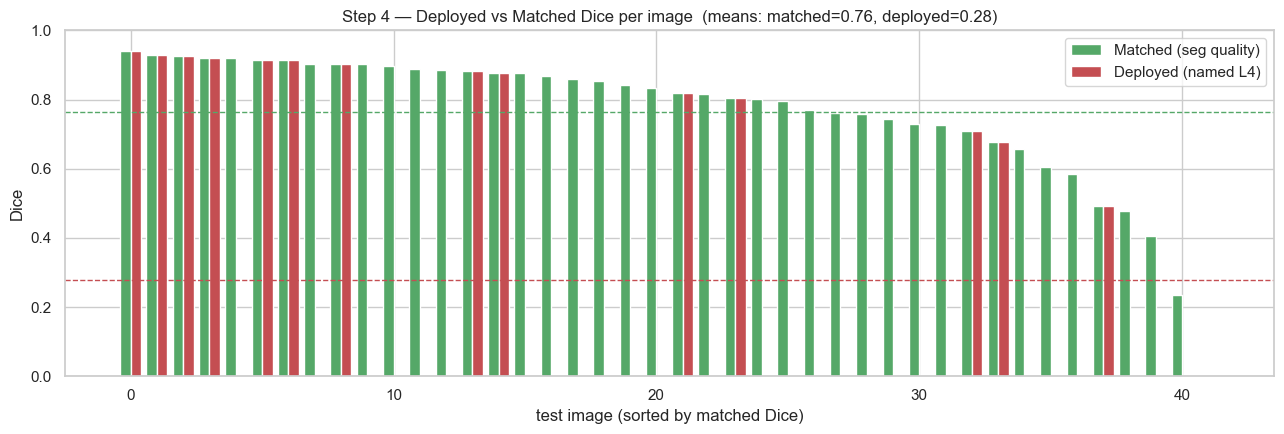

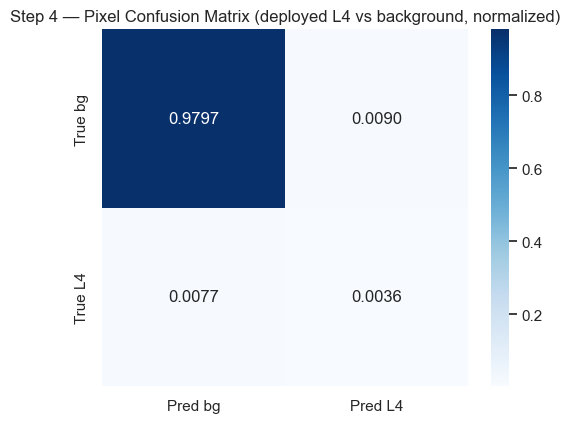

In [11]:
# ---- (1) Diagnostic overlays: where does the 'L4' name land vs the true L4? ----
# red    = mask the model names 'L4' (deployed)
# green  = best-overlap vertebra vs GT (matched)
# yellow = ground-truth L4 contour.   On bad cases red sits ONE vertebra above the yellow GT.
worst = dfm.sort_values("dice").head(4)["file"].tolist()
best  = dfm.sort_values("dice", ascending=False).head(4)["file"].tolist()
show_files = worst + best
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for k, fname in enumerate(show_files):
    dp = next(p for p in eval_items if os.path.basename(p) == fname)
    rgb, _, H, W = load_xray(dp)
    sel, status, inst, r = yolo_instances(rgb)
    gt = load_test_gt_l4(dp, H, W)
    bo_mask, d_match = best_overlap(inst, gt)
    vis = rgb.copy()
    if bo_mask is not None and bo_mask.sum():
        vis[bo_mask > 0] = (0.5*vis[bo_mask > 0] + 0.5*np.array([0, 255, 0])).astype(np.uint8)
    if sel is not None and sel.sum():
        vis[sel > 0]     = (0.5*vis[sel > 0]     + 0.5*np.array([255, 0, 0])).astype(np.uint8)
    if gt is not None:
        cnts, _ = cv2.findContours(gt, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(vis, cnts, -1, (255, 255, 0), 2)
    row = dfm[dfm.file == fname].iloc[0]
    ax = axes[k//4, k % 4]
    ax.imshow(vis); ax.axis("off")
    ax.set_title(f"{'WORST' if k < 4 else 'BEST'}  ...{fname[-10:]}\n"
                 f"deployed={row['dice']:.2f}  matched={row['dice_matched']:.2f}", fontsize=8)
fig.suptitle("Step 4 — named-L4 (red) vs best-overlap vertebra (green) vs GT L4 (yellow)\n"
             "WORST row: red is one vertebra above the yellow GT  =>  off-by-one naming, not bad masks",
             fontsize=12)
plt.tight_layout(); plt.show()

# ---- (2) Per-image Deployed vs Matched Dice (the bimodal split made visible) ----
order = dfm.sort_values("dice_matched", ascending=False).reset_index(drop=True)
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(x - 0.2, order["dice_matched"], width=0.4, label="Matched (seg quality)", color="#55A868")
ax.bar(x + 0.2, order["dice"],         width=0.4, label="Deployed (named L4)",   color="#C44E52")
ax.axhline(order["dice_matched"].mean(), color="#55A868", ls="--", lw=1)
ax.axhline(order["dice"].mean(),         color="#C44E52", ls="--", lw=1)
ax.set_xlabel("test image (sorted by matched Dice)"); ax.set_ylabel("Dice"); ax.set_ylim(0, 1)
ax.set_title(f"Step 4 — Deployed vs Matched Dice per image  "
             f"(means: matched={order['dice_matched'].mean():.2f}, deployed={order['dice'].mean():.2f})")
ax.legend(); plt.tight_layout(); plt.show()

# ---- (3) Pixel confusion matrix (deployed L4 vs background) ----
fig, ax = plt.subplots(figsize=(5.2, 4.4))
sns.heatmap(cm_total / cm_total.sum(), annot=True, fmt=".4f", cmap="Blues",
            xticklabels=["Pred bg", "Pred L4"], yticklabels=["True bg", "True L4"], ax=ax)
ax.set_title("Step 4 — Pixel Confusion Matrix (deployed L4 vs background, normalized)")
plt.tight_layout(); plt.show()

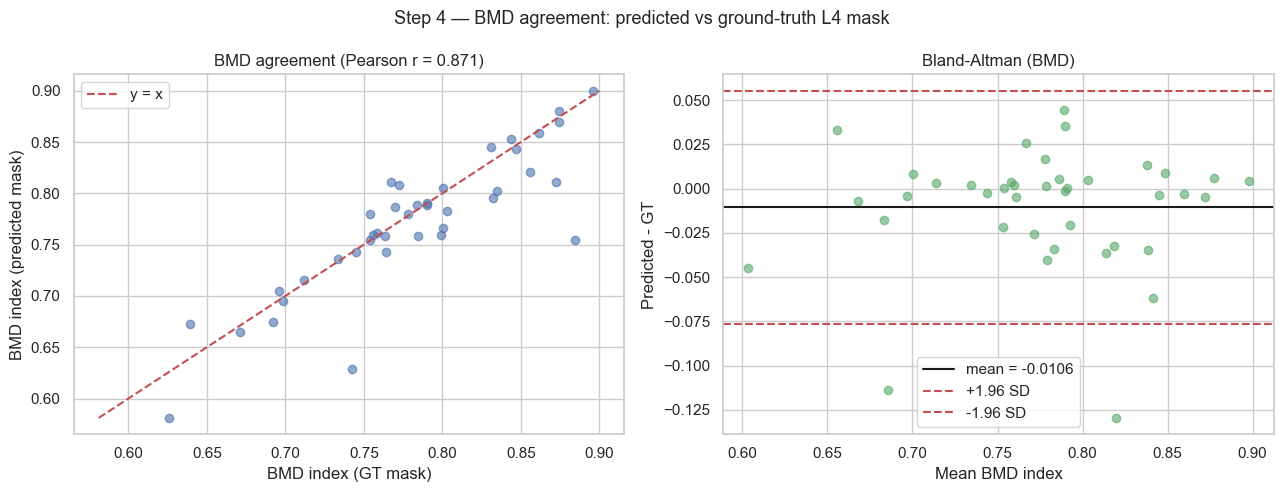

In [12]:
# ---- Bland-Altman + correlation of BMD (predicted vs GT mask) ----
bmd_pred = np.array(bmd_pred); bmd_gt = np.array(bmd_gt)
if len(bmd_gt) >= 2:
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    ax[0].scatter(bmd_gt, bmd_pred, alpha=0.6, color="#4C72B0")
    lims = [min(bmd_gt.min(), bmd_pred.min()), max(bmd_gt.max(), bmd_pred.max())]
    ax[0].plot(lims, lims, "r--", label="y = x")
    r = np.corrcoef(bmd_gt, bmd_pred)[0, 1]
    ax[0].set_title(f"BMD agreement (Pearson r = {r:.3f})")
    ax[0].set_xlabel("BMD index (GT mask)"); ax[0].set_ylabel("BMD index (predicted mask)"); ax[0].legend()
    mean_b = (bmd_pred + bmd_gt) / 2.0; diff_b = bmd_pred - bmd_gt
    mdv, sdv = diff_b.mean(), diff_b.std()
    ax[1].scatter(mean_b, diff_b, alpha=0.6, color="#55A868")
    ax[1].axhline(mdv, color="k", label=f"mean = {mdv:.4f}")
    ax[1].axhline(mdv + 1.96*sdv, color="r", ls="--", label="+1.96 SD")
    ax[1].axhline(mdv - 1.96*sdv, color="r", ls="--", label="-1.96 SD")
    ax[1].set_xlabel("Mean BMD index"); ax[1].set_ylabel("Predicted - GT")
    ax[1].set_title("Bland-Altman (BMD)"); ax[1].legend()
    fig.suptitle("Step 4 — BMD agreement: predicted vs ground-truth L4 mask", fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print("Not enough paired BMD samples for a Bland-Altman plot.")

## Step 5 — Modular Inference (pre-trained model)

`infer_l4(path)` accepts any raw X-ray (**JPG/PNG or DICOM**), runs YOLO segmentation, and returns +
plots the **L4 BMD and GLCM** metrics.

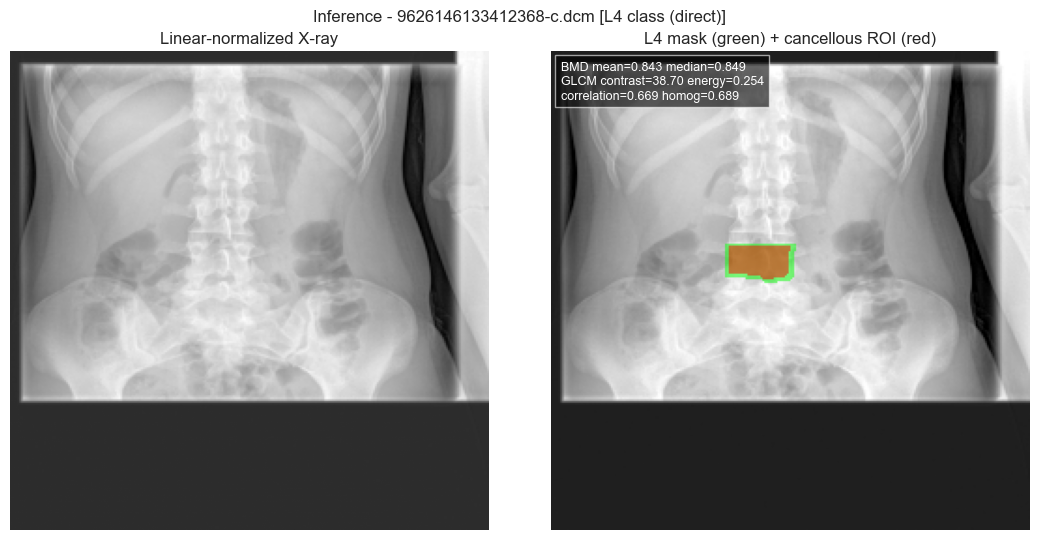

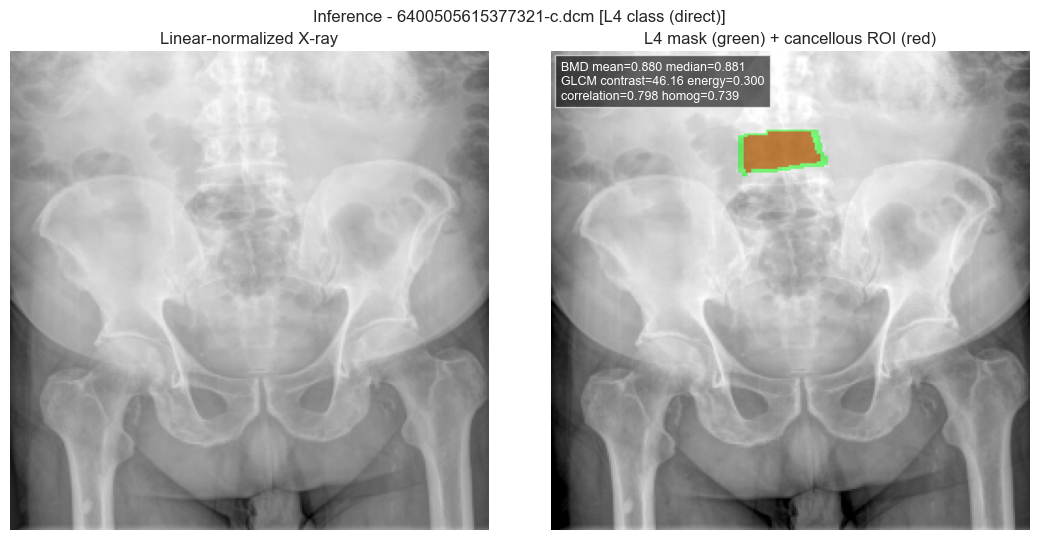

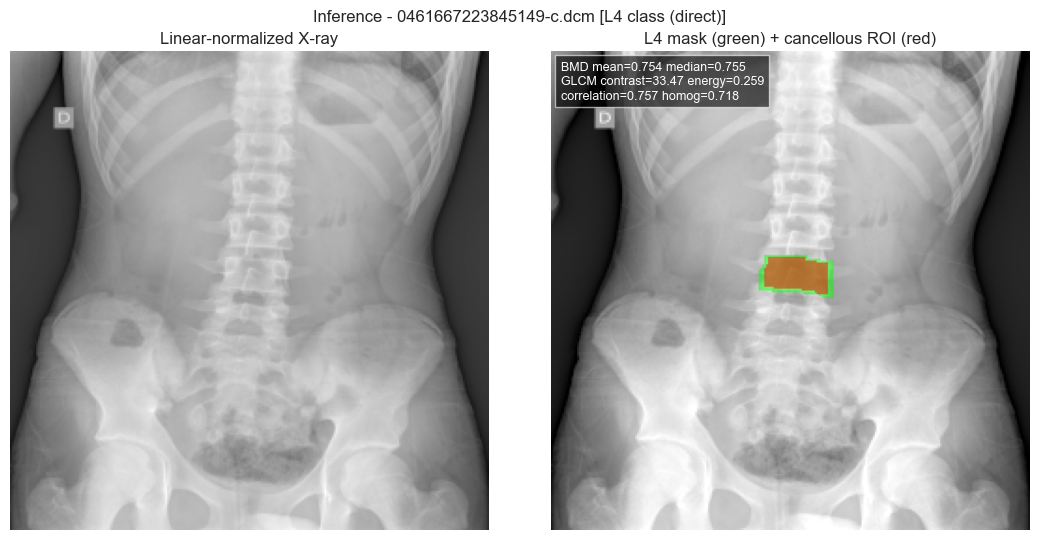

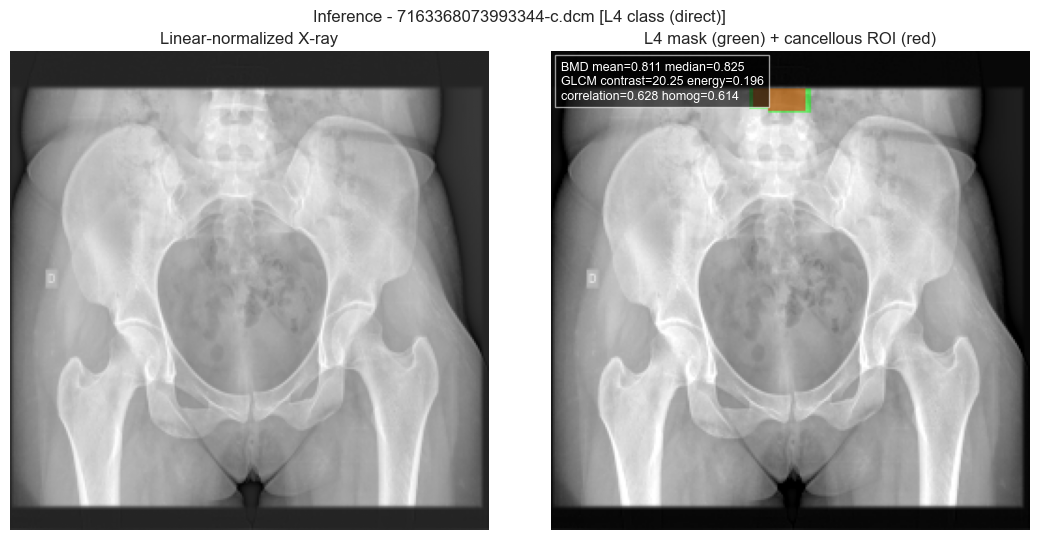

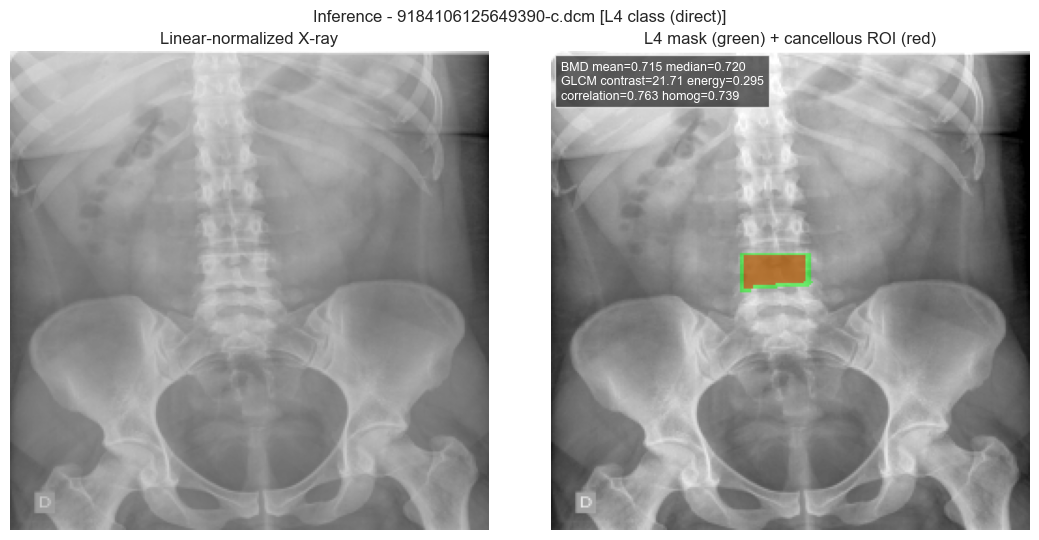

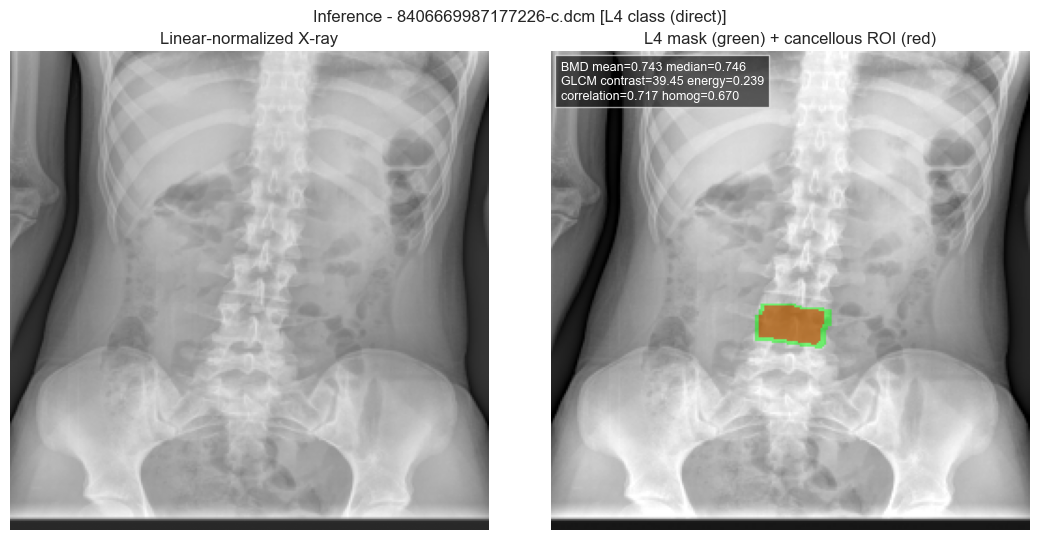

Saved metrics for 42 images -> ./l4_v4_output\L4_test_metrics.csv


,file,status,area_px,bmd_mean,bmd_median,bmd_std,bmd_p10,bmd_p90,glcm_contrast,glcm_correlation,glcm_energy,glcm_homogeneity
0,1.2.826.0.1.3680043.8.498.10406657579016312201...,L4 class (direct),523.0,0.843422,0.849016,0.046264,0.784662,0.896339,38.698216,0.668770,0.253585,0.688850
1,1.2.826.0.1.3680043.8.498.10947130043296900260...,L4 class (direct),702.0,0.880302,0.880947,0.032723,0.838859,0.921574,46.160300,0.798313,0.300195,0.738608
2,1.2.826.0.1.3680043.8.498.11121020226184051416...,L4 class (direct),560.0,0.754180,0.754922,0.043468,0.693177,0.811456,33.470446,0.757155,0.258676,0.718445
3,1.2.826.0.1.3680043.8.498.11207126462590105123...,L4 class (direct),320.0,0.810675,0.824580,0.075438,0.721076,0.893337,20.248337,0.627842,0.195870,0.613695
4,1.2.826.0.1.3680043.8.498.11227155170490832168...,L4 class (direct),521.0,0.715132,0.719706,0.039422,0.656048,0.763232,21.705706,0.763090,0.295484,0.739407
5,1.2.826.0.1.3680043.8.498.11430185427783861938...,L4 class (direct),595.0,0.742523,0.745762,0.051557,0.660379,0.802537,39.449776,0.717295,0.239170,0.669932
6,1.2.826.0.1.3680043.8.498.11479964994316715381...,L4 class (direct),677.0,0.805560,0.813828,0.054791,0.723028,0.872858,11.525174,0.708874,0.221687,0.682027
7,1.2.826.0.1.3680043.8.498.11666143137939211262...,L4 class (direct),603.0,0.735561,0.737562,0.058420,0.656769,0.813427,11.126030,0.704694,0.190471,0.606660
8,1.2.826.0.1.3680043.8.498.12209232711532162247...,L4 class (direct),386.0,0.807679,0.810214,0.048106,0.744860,0.866923,27.188929,0.259515,0.243126,0.642237
9,1.2.826.0.1.3680043.8.498.12608809850577365286...,L4 class (direct),523.0,0.790730,0.793892,0.062030,0.710406,0.867439,2.543152,0.732646,0.205566,0.629842


In [13]:
def infer_l4(path, show=True):
    rgb, gray_lin, H, W = load_xray(path)
    m, status, r = yolo_l4(rgb)
    metrics = {"file": os.path.basename(path), "status": status}
    if m is None or m.sum() == 0:
        if show:
            plt.figure(figsize=(5, 5)); plt.imshow(rgb); plt.title(f"{status} (no L4)"); plt.axis("off"); plt.show()
        return metrics
    roi = shrink_mask(m)
    bmd = compute_bmd(gray_lin, roi); glcm = compute_glcm(gray_lin, roi)
    if bmd:  metrics.update(bmd)
    if glcm: metrics.update(glcm)
    if show:
        vis = rgb.copy()
        vis[m > 0]   = (0.5*vis[m > 0]   + 0.5*np.array([0, 255, 0])).astype(np.uint8)
        vis[roi > 0] = (0.5*vis[roi > 0] + 0.5*np.array([255, 0, 0])).astype(np.uint8)
        fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
        ax[0].imshow(gray_lin, cmap="gray"); ax[0].set_title("Linear-normalized X-ray"); ax[0].axis("off")
        ax[1].imshow(vis); ax[1].axis("off"); ax[1].set_title("L4 mask (green) + cancellous ROI (red)")
        if bmd and glcm:
            txt = (f"BMD mean={bmd['bmd_mean']:.3f} median={bmd['bmd_median']:.3f}\n"
                   f"GLCM contrast={glcm['glcm_contrast']:.2f} energy={glcm['glcm_energy']:.3f}\n"
                   f"correlation={glcm['glcm_correlation']:.3f} homog={glcm['glcm_homogeneity']:.3f}")
            ax[1].text(0.02, 0.98, txt, transform=ax[1].transAxes, va="top", fontsize=9,
                       color="white", bbox=dict(facecolor="black", alpha=0.6))
        fig.suptitle(f"Inference - {os.path.basename(path)[-22:]} [{status}]", fontsize=12)
        plt.tight_layout(); plt.show()
    return metrics

results = [infer_l4(p, show=(k < 6)) for k, p in enumerate(eval_items)]
res_df = pd.DataFrame(results)
res_df.to_csv(os.path.join(OUT_DIR, "L4_test_metrics.csv"), index=False)
print(f"Saved metrics for {len(res_df)} images -> {os.path.join(OUT_DIR, 'L4_test_metrics.csv')}")
display(res_df.head(10))

## Step 6 — Save Spine/L4 Extraction Results for the Test Set

Every DICOM test image is processed and its extraction artifacts are written to
`./l4_v3_output/segmentation/`:
- `<id>_overlay.png` — all detected vertebrae (blue) with the L4 mask (green),
- `<id>_L4mask.png` — the binary L4 mask,
- `L4_extraction_summary.csv` — per-image status + BMD + GLCM metrics.

In [14]:
SEG_DIR = os.path.join(OUT_DIR, "segmentation")
os.makedirs(SEG_DIR, exist_ok=True)

save_rows = []
for dp in test_dcm_files:
    stem = os.path.splitext(os.path.basename(dp))[0]
    rgb, gray_lin, H, W = load_xray(dp)
    m, status, r = yolo_l4(rgb)
    rec = {"file": os.path.basename(dp), "status": status}
    if m is not None and m.sum() > 0:
        roi  = shrink_mask(m)
        bmd  = compute_bmd(gray_lin, roi)
        glcm = compute_glcm(gray_lin, roi)
        if bmd:  rec.update(bmd)
        if glcm: rec.update(glcm)
        vis = rgb.copy()
        if r.masks is not None:
            for poly in r.masks.xy:
                cv2.polylines(vis, [poly.astype(np.int32)], True, (80, 160, 255), 2)
        vis[m > 0] = (0.5*vis[m > 0] + 0.5*np.array([0, 255, 0])).astype(np.uint8)
        cv2.imwrite(os.path.join(SEG_DIR, stem + "_overlay.png"), cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))
        cv2.imwrite(os.path.join(SEG_DIR, stem + "_L4mask.png"), (m * 255).astype(np.uint8))
    save_rows.append(rec)

summary = pd.DataFrame(save_rows)
summary.to_csv(os.path.join(SEG_DIR, "L4_extraction_summary.csv"), index=False)
n_ok = int((summary["status"].astype(str).str.contains("L4")).sum() +
           (summary["status"].astype(str).str.contains("4th")).sum())
print(f"Saved {len(summary)} results to {SEG_DIR} "
      f"(overlay+mask images + L4_extraction_summary.csv); L4 found in {n_ok}/{len(summary)}.")
display(summary.head(10))

Saved 42 results to ./l4_v4_output\segmentation (overlay+mask images + L4_extraction_summary.csv); L4 found in 40/42.


,file,status,area_px,bmd_mean,bmd_median,bmd_std,bmd_p10,bmd_p90,glcm_contrast,glcm_correlation,glcm_energy,glcm_homogeneity
0,1.2.826.0.1.3680043.8.498.10406657579016312201...,L4 class (direct),523.0,0.843422,0.849016,0.046264,0.784662,0.896339,38.698216,0.668770,0.253585,0.688850
1,1.2.826.0.1.3680043.8.498.10947130043296900260...,L4 class (direct),702.0,0.880302,0.880947,0.032723,0.838859,0.921574,46.160300,0.798313,0.300195,0.738608
2,1.2.826.0.1.3680043.8.498.11121020226184051416...,L4 class (direct),560.0,0.754180,0.754922,0.043468,0.693177,0.811456,33.470446,0.757155,0.258676,0.718445
3,1.2.826.0.1.3680043.8.498.11207126462590105123...,L4 class (direct),320.0,0.810675,0.824580,0.075438,0.721076,0.893337,20.248337,0.627842,0.195870,0.613695
4,1.2.826.0.1.3680043.8.498.11227155170490832168...,L4 class (direct),521.0,0.715132,0.719706,0.039422,0.656048,0.763232,21.705706,0.763090,0.295484,0.739407
5,1.2.826.0.1.3680043.8.498.11430185427783861938...,L4 class (direct),595.0,0.742523,0.745762,0.051557,0.660379,0.802537,39.449776,0.717295,0.239170,0.669932
6,1.2.826.0.1.3680043.8.498.11479964994316715381...,L4 class (direct),677.0,0.805560,0.813828,0.054791,0.723028,0.872858,11.525174,0.708874,0.221687,0.682027
7,1.2.826.0.1.3680043.8.498.11666143137939211262...,L4 class (direct),603.0,0.735561,0.737562,0.058420,0.656769,0.813427,11.126030,0.704694,0.190471,0.606660
8,1.2.826.0.1.3680043.8.498.12209232711532162247...,L4 class (direct),386.0,0.807679,0.810214,0.048106,0.744860,0.866923,27.188929,0.259515,0.243126,0.642237
9,1.2.826.0.1.3680043.8.498.12608809850577365286...,L4 class (direct),523.0,0.790730,0.793892,0.062030,0.710406,0.867439,2.543152,0.732646,0.205566,0.629842


## 3. Explainable AI

Two complementary explanations, following the approach in `005-0614_L4_segmentation_BMD.ipynb`.

### XAI 1 — Seg-Grad-CAM (segmentation explanation)
A **true gradient-based** Grad-CAM, replacing the v4 gradient-free Eigen-CAM (whose heatmap landed
off-target). We adopt the **`SemanticSegmentationTarget`** idea from the reference (pytorch-grad-cam)
and adapt it to YOLOv8-seg, which is an instance model rather than a plain `smp` semantic net:

- target scalar = the **L4 instance mask probability** — the mask is reconstructed from the matched
  anchor's coefficients x prototypes and **cropped to the L4 box** so only L4 is explained,
- it is back-propagated to a **high-resolution neck layer** (P3, stride 8), and
  Grad-CAM = ReLU(sum_k a_k A_k) with a_k = mean gradient of the target w.r.t. activation channel k.

The **full** panel shows the network attends to the vertebral column (shared features fire on all
vertebrae); the **L4-focused / zoomed** panels isolate the L4 body and its trabecular structure.

### XAI 2 — BMD-contribution heatmap (measurement explanation)
Since the BMD index is the **mean linear intensity inside the L4 ROI**, the honest explanation of the
*measurement* is the intensity distribution itself. The ROI intensity heatmap + histogram show exactly
which pixels drive the reported value (the model-agnostic XAI used in section 9-2 of the reference).

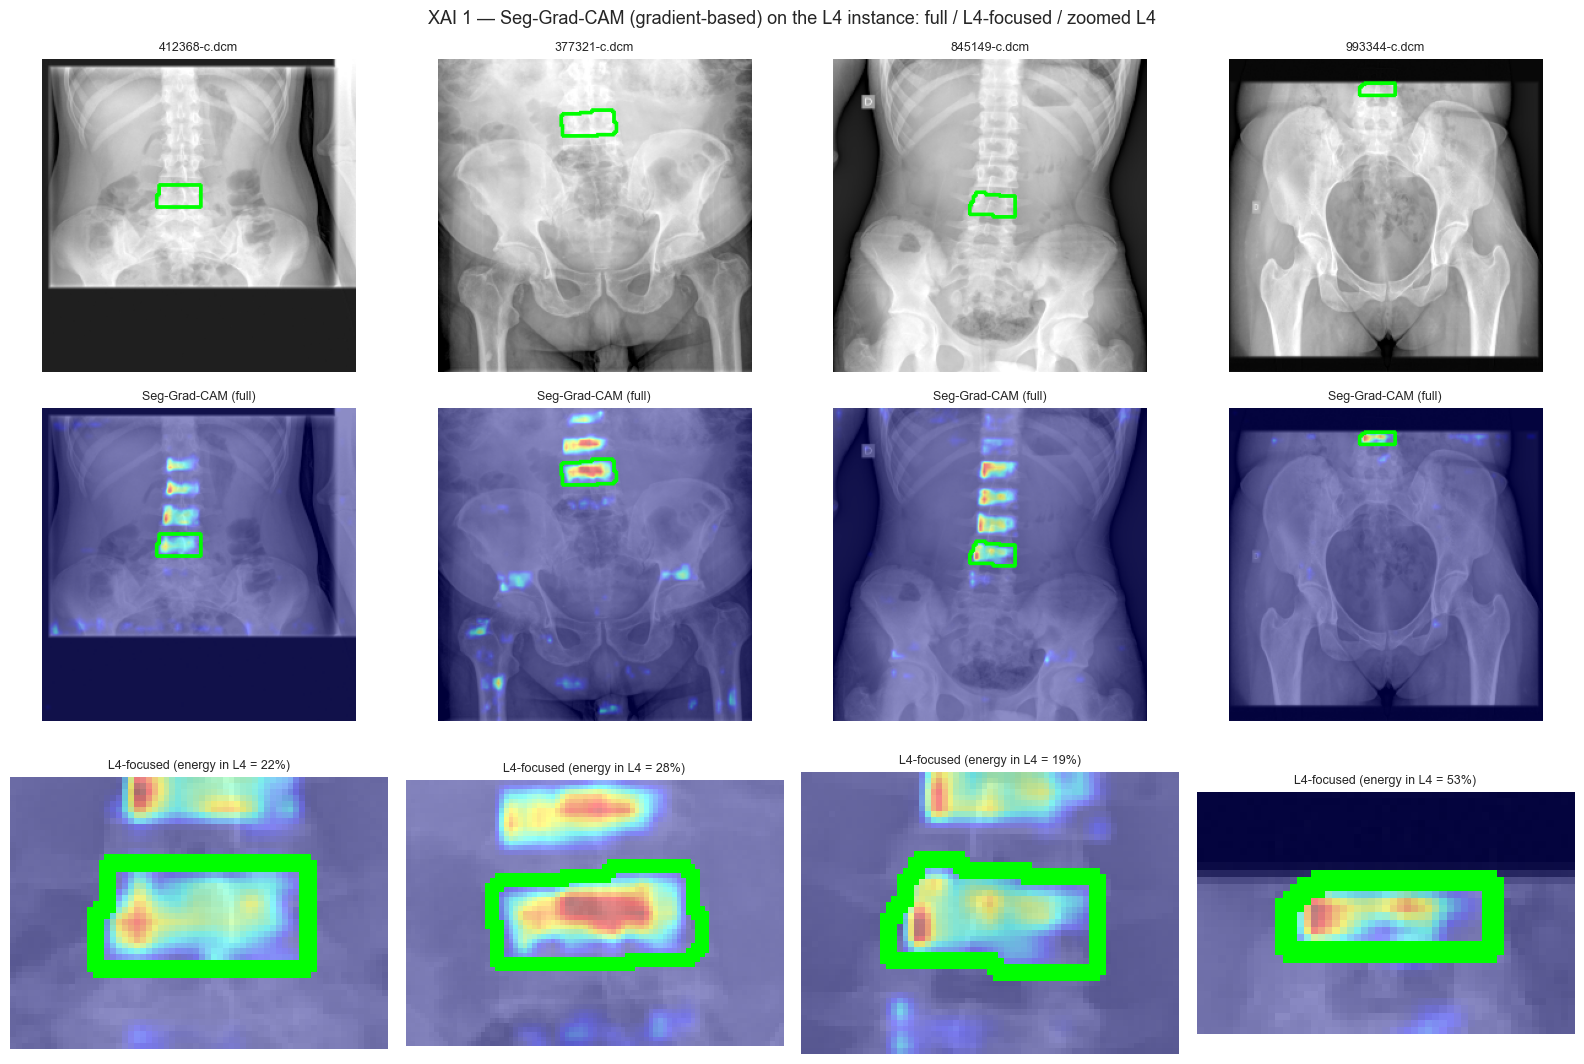

In [15]:
# ============================================================================
#  XAI 1 — Seg-Grad-CAM (TRUE gradient-based) on the L4 instance
#  Adapts the reference's pytorch-grad-cam `SemanticSegmentationTarget` to
#  YOLOv8-seg: the target scalar is the L4 *instance* mask probability (matched
#  anchor coeffs x prototypes, cropped to the L4 box), back-propagated to a
#  high-resolution neck layer (P3, stride 8). This replaces v4's gradient-free
#  Eigen-CAM, whose heatmap landed off the L4 body.
# ============================================================================
import torch
from ultralytics.data.augment import LetterBox

# Dedicated model instance for autograd. The pipeline's `seg` has been run through many
# `predict` calls, which cache anchor buffers as *inference-mode* tensors that cannot enter
# an autograd graph ("Inference tensors cannot be saved for backward"). A fresh load that we
# never call predict on keeps its head buffers as normal tensors.
_NET   = YOLO(YOLO_WEIGHTS).model.eval()
_DEV   = next(_NET.parameters()).device
_IMGSZ = 640
_PROTO = _IMGSZ // 4          # prototype-mask resolution (160)
_CAM_LAYER = 15               # P3 / stride-8 neck feature (highest-res head input)

def l4_focus_weight(mask, ksize=41):
    '''Soft Gaussian weighting around the L4 mask for ROI-focused attribution.'''
    d = cv2.dilate(mask.astype(np.uint8), np.ones((ksize, ksize), np.uint8), 1).astype(np.float32)
    d = cv2.GaussianBlur(d, (ksize, ksize), 0)
    return d / (d.max() + 1e-6)

def seg_grad_cam(img_bgr, layer_idx=_CAM_LAYER, cls_idx=L4_IDX):
    '''Gradient-based Seg-Grad-CAM for the chosen-class instance.
       Returns (cam[H,W] in [0,1], l4_mask[H,W] bool) in the ORIGINAL image frame.'''
    h0, w0 = img_bgr.shape[:2]
    r = min(_IMGSZ / h0, _IMGSZ / w0)
    nw, nh = round(w0 * r), round(h0 * r)
    pw, ph = (_IMGSZ - nw) // 2, (_IMGSZ - nh) // 2
    im = LetterBox((_IMGSZ, _IMGSZ), auto=False)(image=img_bgr)
    t = torch.from_numpy(im[:, :, ::-1].transpose(2, 0, 1).copy()).float().unsqueeze(0).to(_DEV) / 255.0
    t.requires_grad_(True)

    acts, grads = {}, {}
    layer = _NET.model[layer_idx]
    h1 = layer.register_forward_hook(lambda m, i, o: acts.__setitem__('a', o))
    h2 = layer.register_full_backward_hook(lambda m, gi, go: grads.__setitem__('g', go[0]))
    try:
        _NET.model[-1].shape = None                             # force anchor recompute under autograd
        with torch.enable_grad():
            det, proto = _NET(t)[0]                              # det [1,4+NC+32,A], proto [1,32,160,160]
        nc = len(CLASS_NAMES)
        a = torch.argmax(det[0, 4:4 + nc, :][cls_idx]).item()    # best anchor for the class
        cx, cy, bw, bh = [float(v) for v in det[0, 0:4, a]]      # box in 640-space
        coeff = det[0, 4 + nc:, a]                               # 32 mask coefficients
        prob = torch.sigmoid((coeff[:, None, None] * proto[0]).sum(0))   # [160,160]
        crop = torch.zeros_like(prob)                            # crop to the L4 box -> L4 only
        x0, y0 = max(0, int((cx - bw / 2) / 4)), max(0, int((cy - bh / 2) / 4))
        x1, y1 = min(_PROTO, int((cx + bw / 2) / 4)), min(_PROTO, int((cy + bh / 2) / 4))
        crop[y0:y1, x0:x1] = 1.0
        prob_l4 = prob * crop
        mfloat = (prob_l4 > 0.5).float().detach()
        if mfloat.sum() < 1:
            mfloat = crop.detach()
        _NET.zero_grad()
        (prob_l4 * mfloat).sum().backward()                      # SemanticSegmentationTarget scalar
        A  = acts['a'][0].detach()                               # [C,h,w]
        Gw = grads['g'][0].detach().mean(dim=(1, 2))             # GAP of gradients
        cam = torch.relu((Gw[:, None, None] * A).sum(0)).cpu().numpy()
    finally:
        h1.remove(); h2.remove()

    def _unletter(x, interp):                                    # undo letterbox -> original frame
        x = cv2.resize(x, (_IMGSZ, _IMGSZ), interpolation=interp)[ph:ph + nh, pw:pw + nw]
        return cv2.resize(x, (w0, h0), interpolation=interp)
    cam = _unletter(cam.astype(np.float32), cv2.INTER_LINEAR)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-6)
    l4m = _unletter(mfloat.cpu().numpy().astype(np.float32), cv2.INTER_NEAREST) > 0.5
    return cam, l4m

def _energy_in(cam, mask):
    c = np.maximum(cam, 0)
    return float(c[mask].sum() / (c.sum() + 1e-9)) if mask.any() else 0.0

# ---- Visualization: full Grad-CAM (honest) + L4-focused + zoomed L4 ----
xai_samples = eval_items[:4] if eval_items else buu_imgs[:4]
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for k, p in enumerate(xai_samples):
    rgb, _, H, W = load_xray(p)
    img_bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    cam, l4m = seg_grad_cam(img_bgr)
    cnts, _ = cv2.findContours(l4m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    disp = rgb.copy(); cv2.drawContours(disp, cnts, -1, (0, 255, 0), 2)
    axes[0, k].imshow(disp); axes[0, k].set_title(os.path.basename(p)[-12:], fontsize=9); axes[0, k].axis("off")

    heat = cv2.cvtColor(cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    full = (0.55 * rgb + 0.45 * heat).astype(np.uint8); cv2.drawContours(full, cnts, -1, (0, 255, 0), 2)
    axes[1, k].imshow(full); axes[1, k].set_title("Seg-Grad-CAM (full)", fontsize=9); axes[1, k].axis("off")

    if l4m.any():
        foc = cam * l4_focus_weight(l4m); foc = foc / (foc.max() + 1e-6)
        e = _energy_in(cam, l4m)
        ys, xs = np.where(l4m); pad = int(0.4 * max(np.ptp(ys) + 1, np.ptp(xs) + 1))
        y0, y1 = max(0, ys.min() - pad), min(H, ys.max() + pad)
        x0, x1 = max(0, xs.min() - pad), min(W, xs.max() + pad)
        fheat = cv2.cvtColor(cv2.applyColorMap((foc * 255).astype(np.uint8), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
        fblend = (0.55 * rgb + 0.45 * fheat).astype(np.uint8); cv2.drawContours(fblend, cnts, -1, (0, 255, 0), 2)
        axes[2, k].imshow(fblend[y0:y1, x0:x1])
        axes[2, k].set_title(f"L4-focused (energy in L4 = {e*100:.0f}%)", fontsize=9)
    axes[2, k].axis("off")
fig.suptitle("XAI 1 — Seg-Grad-CAM (gradient-based) on the L4 instance: full / L4-focused / zoomed L4", fontsize=13)
plt.tight_layout(); plt.show()


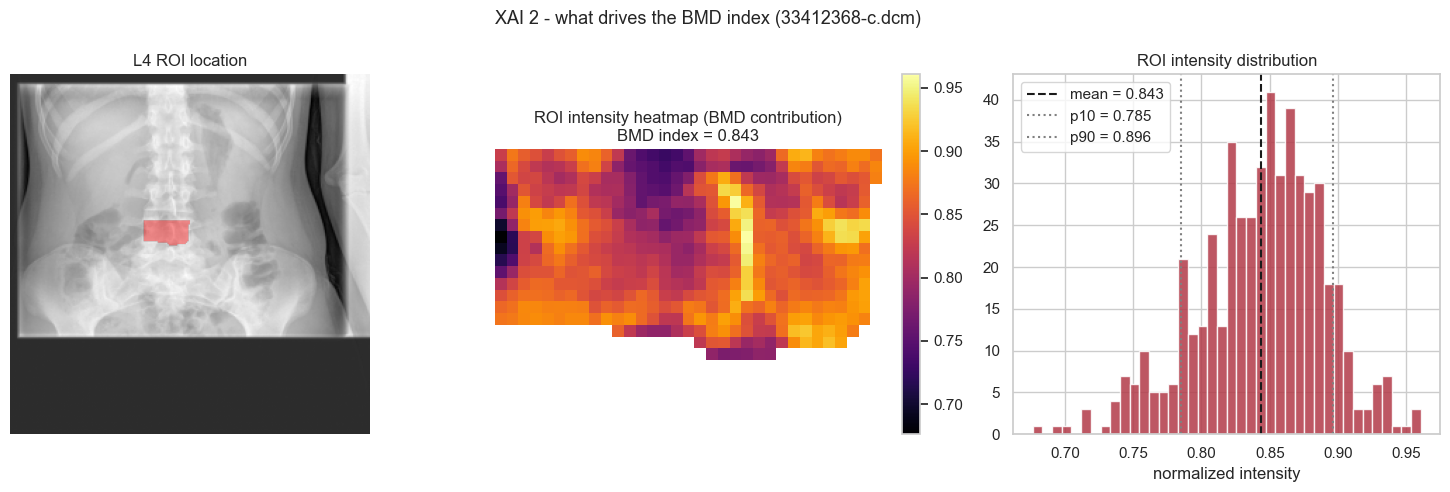

In [16]:
# ============================================================================
#  XAI 2 — BMD-contribution heatmap (measurement explanation, model-agnostic)
#  The BMD index is the mean LINEAR intensity inside the L4 ROI, so the honest
#  explanation of the *measurement* is the ROI intensity distribution itself.
#  (Mirrors section 9-2 of 005-0614_L4_segmentation_BMD.ipynb.)
# ============================================================================
p = (eval_items[:1] or buu_imgs[:1])[0]
rgb, gray_lin, H, W = load_xray(p)
m, status, r = yolo_l4(rgb)
if m is not None and m.sum():
    roi = shrink_mask(m)
    ys, xs = np.where(roi > 0); y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
    patch = gray_lin[y0:y1 + 1, x0:x1 + 1].copy().astype(np.float32)
    patch[roi[y0:y1 + 1, x0:x1 + 1] == 0] = np.nan          # show ROI pixels only
    bmd = compute_bmd(gray_lin, roi)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(gray_lin, cmap="gray")
    ax[0].imshow(np.ma.masked_where(roi == 0, roi), cmap="autumn", alpha=0.4)
    ax[0].set_title("L4 ROI location"); ax[0].axis("off")

    im = ax[1].imshow(patch, cmap="inferno")
    ax[1].set_title(f"ROI intensity heatmap (BMD contribution)\nBMD index = {bmd['bmd_mean']:.3f}")
    ax[1].axis("off"); plt.colorbar(im, ax=ax[1], fraction=0.046)

    ax[2].hist(gray_lin[roi > 0].ravel(), bins=40, color="#B23A48", alpha=0.85)
    ax[2].axvline(bmd['bmd_mean'], color="k",    ls="--", label=f"mean = {bmd['bmd_mean']:.3f}")
    ax[2].axvline(bmd['bmd_p10'],  color="gray", ls=":",  label=f"p10 = {bmd['bmd_p10']:.3f}")
    ax[2].axvline(bmd['bmd_p90'],  color="gray", ls=":",  label=f"p90 = {bmd['bmd_p90']:.3f}")
    ax[2].set_title("ROI intensity distribution"); ax[2].set_xlabel("normalized intensity"); ax[2].legend()
    fig.suptitle(f"XAI 2 - what drives the BMD index ({os.path.basename(p)[-14:]})", fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print("No L4 detected on the sample; cannot draw the BMD-contribution heatmap.")


## Appendix — Training details

Training is now an **active, guarded step** in *Step 2* (set `RETRAIN=True` to rebuild `best.pt` from BUU-LSPINE-2000). The standalone conversion/train snippet below is kept for reference only.


In [17]:
# import shutil
# YOLO_ROOT = "./yolo_ap_seg"; VAL_RATIO = 0.15
# def _rows(path):
#     out=[]
#     for line in open(path):
#         nums=re.findall(r"-?\d+\.?\d*", line)
#         if len(nums)>=4: out.append([float(v) for v in nums[:4]])
#     return out
# def order_quad(pts):
#     pts=sorted(pts,key=lambda p:p[1]); top=sorted(pts[:2],key=lambda p:p[0]); bot=sorted(pts[2:],key=lambda p:p[0])
#     return [top[0],top[1],bot[1],bot[0]]
# def parse_polys(path):
#     rows=_rows(path)
#     if len(rows)<10: return []
#     verts=[]
#     for i in range(5):
#         pts=[]
#         for j in range(2):
#             xL,yL,xR,yR=rows[i*2+j]; pts+=[(xL,yL),(xR,yR)]
#         q=order_quad(pts); verts.append((sum(p[1] for p in q)/4,q))
#     verts.sort(key=lambda v:v[0]); return [q for _,q in verts]
# for sub in ["images/train","images/val","labels/train","labels/val"]:
#     os.makedirs(os.path.join(YOLO_ROOT,sub),exist_ok=True)
# lbls=sorted(glob.glob(os.path.join(LBL_DIR,"*"))); random.shuffle(lbls)
# nv=int(len(lbls)*VAL_RATIO)
# for k,lp in enumerate(lbls):
#     stem=os.path.splitext(os.path.basename(lp))[0]
#     ip=next((os.path.join(IMG_DIR,stem+e) for e in (".jpg",".png") if os.path.exists(os.path.join(IMG_DIR,stem+e))),None)
#     polys=parse_polys(lp)
#     if ip is None or len(polys)!=5: continue
#     im=cv2.imread(ip); H,W=im.shape[:2]; split="val" if k<nv else "train"
#     shutil.copy(ip,os.path.join(YOLO_ROOT,"images",split,os.path.basename(ip)))
#     with open(os.path.join(YOLO_ROOT,"labels",split,stem+".txt"),"w") as f:
#         for cid,q in enumerate(polys):
#             coords=" ".join(f"{x/W:.6f} {y/H:.6f}" for x,y in q); f.write(f"{cid} {coords}\n")
# with open(os.path.join(YOLO_ROOT,"data.yaml"),"w") as f:
#     f.write(f"path: {os.path.abspath(YOLO_ROOT)}\ntrain: images/train\nval: images/val\n")
#     f.write(f"nc: {len(CLASS_NAMES)}\nnames: {CLASS_NAMES}\n")
# YOLO("yolov8n-seg.pt").train(data=os.path.join(YOLO_ROOT,"data.yaml"),
#                              epochs=100, imgsz=640, batch=-1, project="ap_seg", name="l1_l5",
#                              patience=20, workers=0)

## Summary

- **Segmentation:** YOLOv8-seg (instance) with a class/4th-from-top L4 selector — reliable L4 masks.
- **BMD:** linear normalized intensity inside the cancellous L4 ROI (relative proxy; calibrate with a
  phantom/DXA for absolute g/cm2).
- **Microarchitecture:** rotation-averaged GLCM (Contrast, Correlation, Energy/ASM, Homogeneity).
- **Evaluation:** dual-metric Dice (Deployed vs Matched) + confusion matrix + Bland-Altman, on the
  DICOM test set against true L4 masks; the Deployed-vs-Matched gap isolates the L4 indexing issue.
- **XAI (v5):** a **true gradient-based Seg-Grad-CAM** on the L4 instance (replacing v4's Eigen-CAM)
  plus a **BMD-contribution intensity heatmap** — attribution now lands on the L4 body/trabeculae.
- **Swappable design:** the segmenter is a module; the from-scratch ResNet-U-Net lives in v2 / 005.